# Time Series Analysis and forcasting for Stock Market

In [ ]:
# import libaries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import datetime # Import the datetime module
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
pip install yfinance

In [ ]:
#load stock data
df = yf.download('META', start='2015-01-01', end='2023-12-31')

#This line filters the DataFrame df to keep only the 'Close' column — which represents the daily closing price of the stock.
df = df[['Close']]

#convert date column to determine
df.index = pd.to_datetime(df.index)
print(df.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           META
Date                 
2015-01-02  78.082001
2015-01-05  76.827911
2015-01-06  75.792793
2015-01-07  75.792793
2015-01-08  77.813263


In [ ]:
#basic financial information
meta = yf.Ticker("META")
print(meta.info)

{'address1': '1 Meta Way', 'city': 'Menlo Park', 'state': 'CA', 'zip': '94025', 'country': 'United States', 'phone': '650 543 4800', 'website': 'https://investor.atmeta.com', 'industry': 'Internet Content & Information', 'industryKey': 'internet-content-information', 'industryDisp': 'Internet Content & Information', 'sector': 'Communication Services', 'sectorKey': 'communication-services', 'sectorDisp': 'Communication Services', 'longBusinessSummary': 'Meta Platforms, Inc. engages in the development of products that enable people to connect and share with friends and family through mobile devices, personal computers, virtual reality and mixed reality headsets, augmented reality, and wearables worldwide. It operates through two segments, Family of Apps (FoA) and Reality Labs (RL). The FoA segment offers Facebook, which enables people to build community through feed, reels, stories, groups, marketplace, and other; Instagram that brings people closer through instagram feed, stories, reels

In [ ]:
#fetch financial key
meta = yf.Ticker("META")
print(meta.financials)
meta = yf.Ticker("META")
print("Company Sector:", meta.info['sector'])
print("P/E Ratio:", meta.info['trailingPE'])
print("Company Beta:", meta.info['beta'])

                                                        2024-12-31  \
Tax Effect Of Unusual Items                            -81420000.0   
Tax Rate For Calcs                                           0.118   
Normalized EBITDA                                    87566000000.0   
Total Unusual Items                                   -690000000.0   
Total Unusual Items Excluding Goodwill                -690000000.0   
Net Income From Continuing Operation Net Minori...   62360000000.0   
Reconciled Depreciation                              15498000000.0   
Reconciled Cost Of Revenue                           30161000000.0   
EBITDA                                               86876000000.0   
EBIT                                                 71378000000.0   
Net Interest Income                                   1973000000.0   
Interest Expense                                       715000000.0   
Interest Income                                       2517000000.0   
Normalized Income   

In [ ]:
#nformation in key-value pairs
meta = yf.Ticker("META")
for key, value in meta.info.items():
    print(f"{key}: {value}")

address1: 1 Meta Way
city: Menlo Park
state: CA
zip: 94025
country: United States
phone: 650 543 4800
website: https://investor.atmeta.com
industry: Internet Content & Information
industryKey: internet-content-information
industryDisp: Internet Content & Information
sector: Communication Services
sectorKey: communication-services
sectorDisp: Communication Services
longBusinessSummary: Meta Platforms, Inc. engages in the development of products that enable people to connect and share with friends and family through mobile devices, personal computers, virtual reality and mixed reality headsets, augmented reality, and wearables worldwide. It operates through two segments, Family of Apps (FoA) and Reality Labs (RL). The FoA segment offers Facebook, which enables people to build community through feed, reels, stories, groups, marketplace, and other; Instagram that brings people closer through instagram feed, stories, reels, live, and messaging; Messenger, a messaging application for people 

In [ ]:
#stock prices history() method
meta = yf.Ticker("META")
data = meta.history(period="max")
print(data.to_string())

                                 Open        High         Low       Close     Volume  Dividends  Stock Splits
Date                                                                                                         
2012-05-18 00:00:00-04:00   41.852747   44.788910   37.821746   38.050667  573576400      0.000           0.0
2012-05-21 00:00:00-04:00   36.358638   36.488029   32.845198   33.870365  168192700      0.000           0.0
2012-05-22 00:00:00-04:00   32.457032   33.432435   30.794866   30.854584  101786600      0.000           0.0
2012-05-23 00:00:00-04:00   31.222848   32.347546   31.212894   31.849892   73600000      0.000           0.0
2012-05-24 00:00:00-04:00   32.795434   33.054213   31.620969   32.875057   50237200      0.000           0.0
2012-05-25 00:00:00-04:00   32.745671   32.795435   30.964067   31.760313   37149800      0.000           0.0
2012-05-29 00:00:00-04:00   31.332327   31.541343   28.515603   28.704712   78063400      0.000           0.0
2012-05-30

In [ ]:
#Getting all the rows of META historical data
meta = yf.Ticker("META")
data = meta.history(period="max")
pd.set_option('display.max_rows', None)
print(data.to_string())

                                 Open        High         Low       Close     Volume  Dividends  Stock Splits
Date                                                                                                         
2012-05-18 00:00:00-04:00   41.852743   44.788905   37.821742   38.050663  573576400      0.000           0.0
2012-05-21 00:00:00-04:00   36.358642   36.488033   32.845202   33.870369  168192700      0.000           0.0
2012-05-22 00:00:00-04:00   32.457028   33.432430   30.794862   30.854580  101786600      0.000           0.0
2012-05-23 00:00:00-04:00   31.222848   32.347546   31.212894   31.849892   73600000      0.000           0.0
2012-05-24 00:00:00-04:00   32.795434   33.054213   31.620969   32.875057   50237200      0.000           0.0
2012-05-25 00:00:00-04:00   32.745671   32.795435   30.964067   31.760313   37149800      0.000           0.0
2012-05-29 00:00:00-04:00   31.332331   31.541347   28.515606   28.704716   78063400      0.000           0.0
2012-05-30

In [ ]:
#Getting Historical Data for a Specific Period
start_date = datetime.datetime(2019, 5, 31)
end_date = datetime.datetime(2021, 1, 30)
meta = yf.Ticker("META")
data = meta.history(start=start_date, end=end_date)
print(data.to_string())

                                 Open        High         Low       Close    Volume  Dividends  Stock Splits
Date                                                                                                        
2019-05-31 00:00:00-04:00  179.434328  179.693103  176.328969  176.637512  15226500        0.0           0.0
2019-06-03 00:00:00-04:00  174.179100  174.228868  160.254720  163.379990  56059600        0.0           0.0
2019-06-04 00:00:00-04:00  162.942049  167.490604  160.085502  166.714264  46044300        0.0           0.0
2019-06-05 00:00:00-04:00  166.694368  167.928557  163.857746  167.381134  19758300        0.0           0.0
2019-06-06 00:00:00-04:00  167.510517  168.903943  166.445529  167.540375  12446400        0.0           0.0
2019-06-07 00:00:00-04:00  169.371759  173.054400  168.047996  172.536850  16917300        0.0           0.0
2019-06-10 00:00:00-04:00  173.930275  177.025687  172.984735  173.999954  14767900        0.0           0.0
2019-06-11 00:00:00

                                 Open        High         Low       Close    Volume  Dividends  Stock Splits
Date                                                                                                        
2024-05-22 00:00:00-04:00  466.169320  471.998062  463.957388  466.079651  10078600      0.000           0.0
2024-05-23 00:00:00-04:00  471.161174  472.635775  459.862396  464.086975  11747900      0.000           0.0
2024-05-24 00:00:00-04:00  465.920274  478.105831  464.605064  476.481750  12012300      0.000           0.0
2024-05-28 00:00:00-04:00  474.847712  479.112153  473.114046  478.175598  10175800      0.000           0.0
2024-05-29 00:00:00-04:00  472.934670  478.105807  471.978168  472.635742   9226200      0.000           0.0
2024-05-30 00:00:00-04:00  469.955558  470.015337  463.020835  465.352325  10735200      0.000           0.0
2024-05-31 00:00:00-04:00  464.106863  467.414802  452.808086  465.133118  16919800      0.000           0.0
2024-06-03 00:00:00

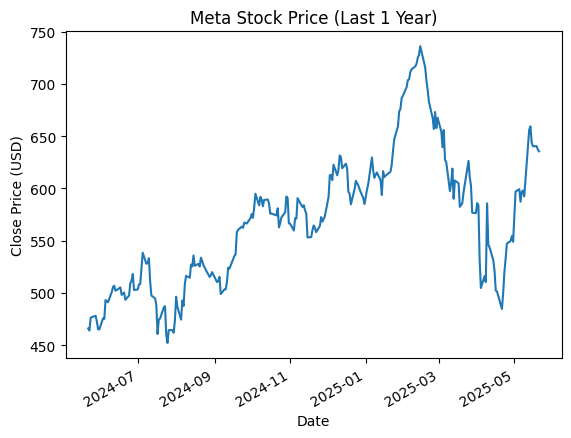

In [ ]:
#Visualize Data and Display in Tabular Format
meta = yf.Ticker("META")
data = meta.history(period="1y")
print(data.to_string())
data['Close'].plot(title="Meta Stock Price (Last 1 Year)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.show()

 Data Cleaning And Featues Engineering

In [ ]:
df.head(5)

Price,Close
Ticker,META
Date,
2015-01-02,78.082001
2015-01-05,76.827911
2015-01-06,75.792793
2015-01-07,75.792793
2015-01-08,77.813263


In [ ]:
df.tail(5)

Price,Close
Ticker,META
Date,
2023-12-22,351.732330
2023-12-26,353.165527
2023-12-27,356.151428
2023-12-28,356.639160
2023-12-29,352.299591


Data Cleaning And Featues Engineering

In [ ]:
#check datatypes and nulls
print(df.info())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2264 entries, 2015-01-02 to 2023-12-29
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, META)  2264 non-null   float64
dtypes: float64(1)
memory usage: 35.4 KB
None


In [ ]:
print(df.describe)

<bound method NDFrame.describe of Price            Close
Ticker            META
Date                  
2015-01-02   78.082001
2015-01-05   76.827911
2015-01-06   75.792793
2015-01-07   75.792793
2015-01-08   77.813263
2015-01-09   77.375336
2015-01-12   76.360115
2015-01-13   76.091377
2015-01-14   75.922173
2015-01-15   73.702644
2015-01-16   74.827339
2015-01-20   75.882370
2015-01-21   76.380020
2015-01-22   77.285751
2015-01-23   77.464905
2015-01-26   77.136459
2015-01-27   75.424522
2015-01-28   75.882370
2015-01-29   77.634109
2015-01-30   75.553917
2015-02-02   74.638229
2015-02-03   75.046310
2015-02-04   75.275238
2015-02-05   75.255318
2015-02-06   74.120674
2015-02-09   74.090813
2015-02-10   74.837296
2015-02-11   76.151100
2015-02-12   75.872421
2015-02-13   75.384705
2015-02-17   75.245369
2015-02-18   76.350166
2015-02-19   79.047455
2015-02-20   79.525200
2015-02-23   78.470169
2015-02-24   78.082001
2015-02-25   79.186790
2015-02-26   80.032806
2015-02-27   78.599556


In [ ]:
#sort by date
#Added inplace=True to sort the DataFrame directly
df.sort_index(ascending=True, inplace=True)

In [ ]:
# Calculate daily returns using the correct column name 'Close'
df['daily_return'] = df['Close'].pct_change()

In [ ]:
df.shape

(2264, 2)

In [ ]:
#check for remaining missing values
print(df.isnull().sum)

<bound method DataFrame.sum of Price       Close daily_return
Ticker       META             
Date                          
2015-01-02  False         True
2015-01-05  False        False
2015-01-06  False        False
2015-01-07  False        False
2015-01-08  False        False
2015-01-09  False        False
2015-01-12  False        False
2015-01-13  False        False
2015-01-14  False        False
2015-01-15  False        False
2015-01-16  False        False
2015-01-20  False        False
2015-01-21  False        False
2015-01-22  False        False
2015-01-23  False        False
2015-01-26  False        False
2015-01-27  False        False
2015-01-28  False        False
2015-01-29  False        False
2015-01-30  False        False
2015-02-02  False        False
2015-02-03  False        False
2015-02-04  False        False
2015-02-05  False        False
2015-02-06  False        False
2015-02-09  False        False
2015-02-10  False        False
2015-02-11  False        False
2015-02-

In [ ]:
#reset index afetr dropping
#reset_index() with drop=True and inplace=True ensures that the resulting DataFrame will have continuous indices, starting from 0 and increasing sequentially
df.reset_index(drop=True, inplace=True)

In [ ]:
#It removes any rows with missing (NaN) values from the DataFrame df
df = df.dropna()

Data Anlysis And Visualization

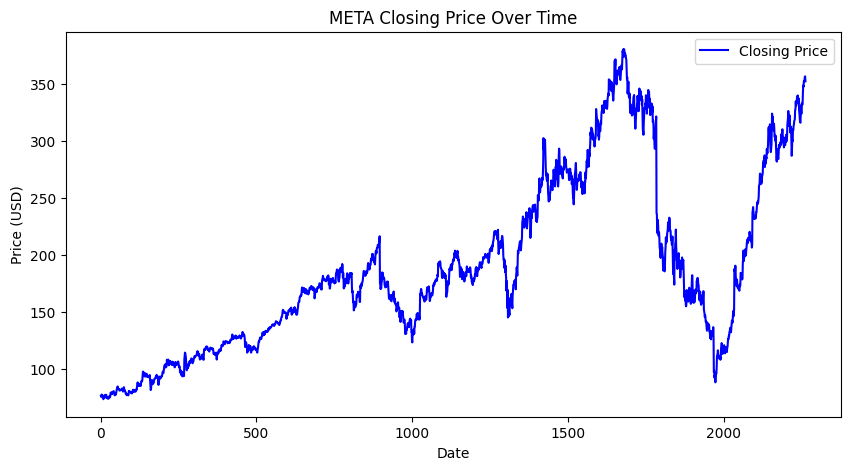

In [ ]:
# Plot the Closing Price
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Close'], label='Closing Price', color='blue')
plt.title("META Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

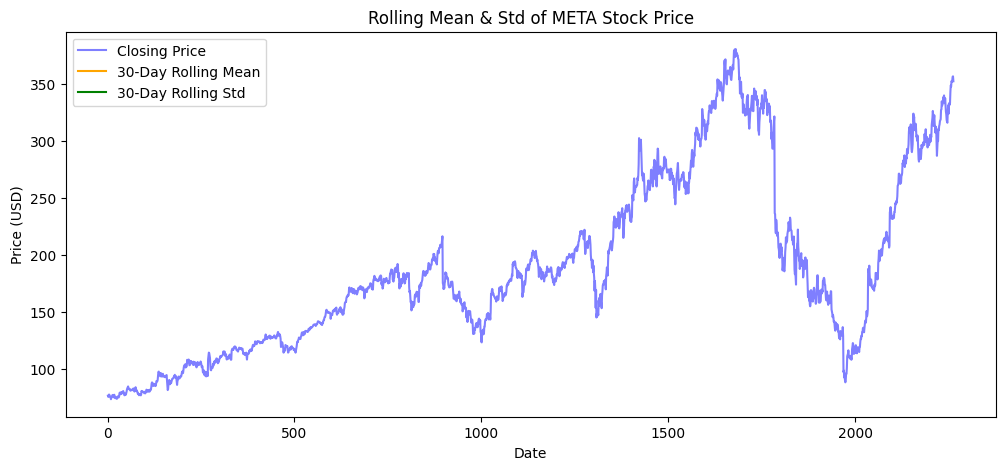

In [ ]:
# Rolling mean and standard deviation (window=30 days)
df['rolling_mean'] = df['Close'].rolling(window=30).mean()
df['rolling_std'] = df['Close'].rolling(window=30).std()
# Plot rolling statistics
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='Closing Price', color='blue', alpha=0.5)
plt.plot(df.index, df['rolling_mean'], label='30-Day Rolling Mean', color='orange')
plt.plot(df.index, df['rolling_std'], label='30-Day Rolling Std', color='green')
plt.title("Rolling Mean & Std of META Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [ ]:
#A classic for traders — shows open, high, low, close (OHLC).
# Use the 'data' DataFrame which contains 'Open', 'High', 'Low', and 'Close' columns
fig = go.Figure(data=[go.Candlestick(x=data.index,
                                     open=data['Open'],
                                     high=data['High'],
                                     low=data['Low'],
                                     close=data['Close'])])
fig.update_layout(title="META Candlestick Chart", xaxis_title="Date", yaxis_title="Price (USD)")
fig.show()

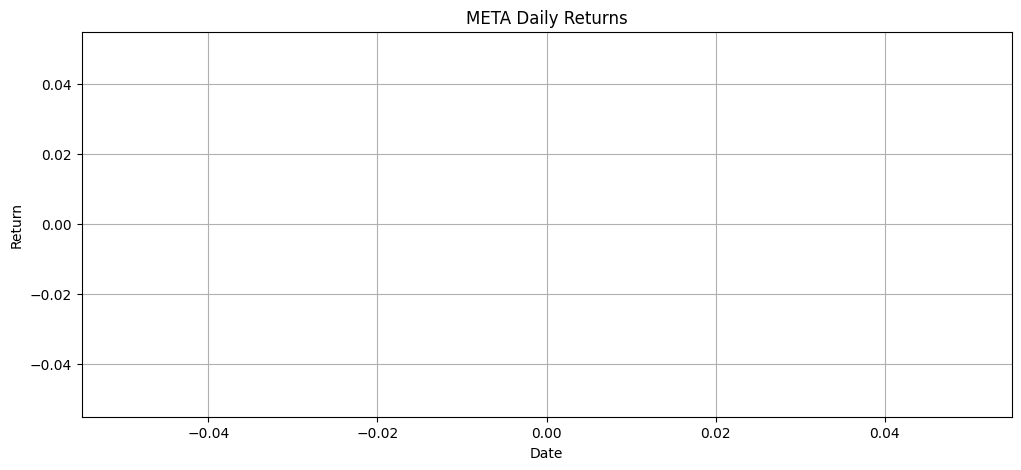

In [ ]:
#visualize day-to-day fluctuations.
df['daily_return'] = df['Close'].pct_change()

plt.figure(figsize=(12, 5))
df['daily_return'].plot(kind='line', color='purple')
plt.title('META Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True)
plt.show()


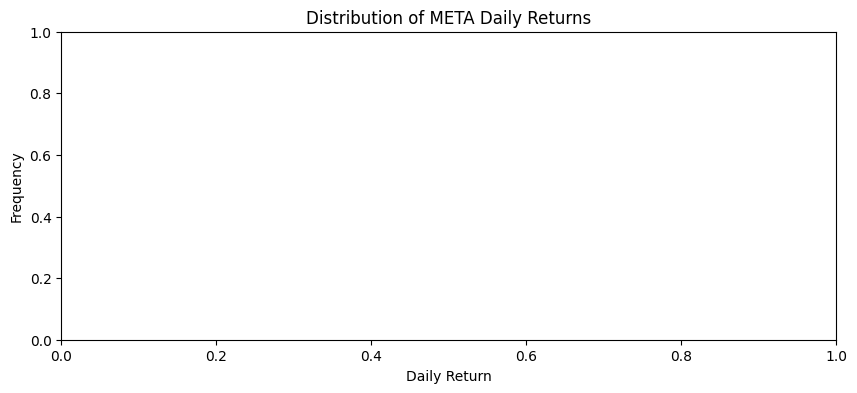

In [ ]:
#Check distribution — helps detect skew, kurtosis, or outliers.
plt.figure(figsize=(10, 4))
sns.histplot(df['daily_return'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of META Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

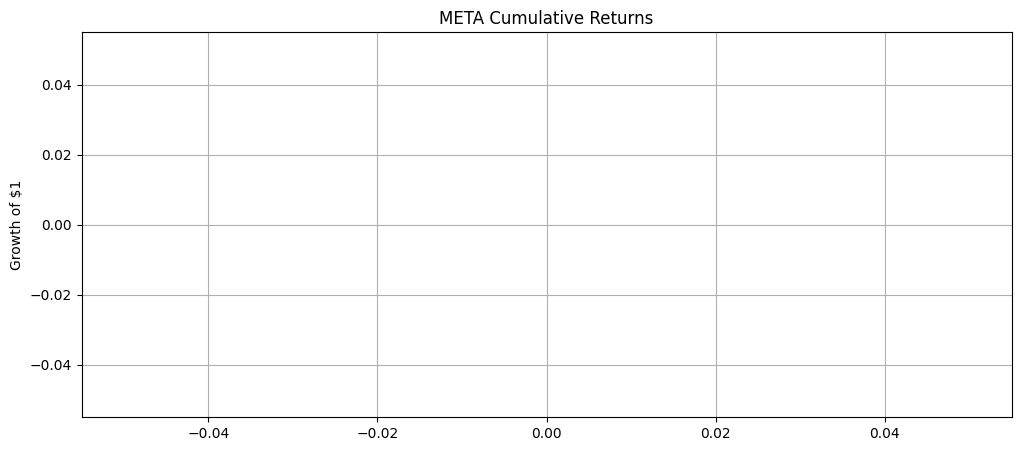

In [ ]:
#Long-term growth of a dollar invested.
df['cumulative_return'] = (1 + df['daily_return']).cumprod()

plt.figure(figsize=(12, 5))
df['cumulative_return'].plot()
plt.title('META Cumulative Returns')
plt.ylabel('Growth of $1')
plt.grid(True)
plt.show()

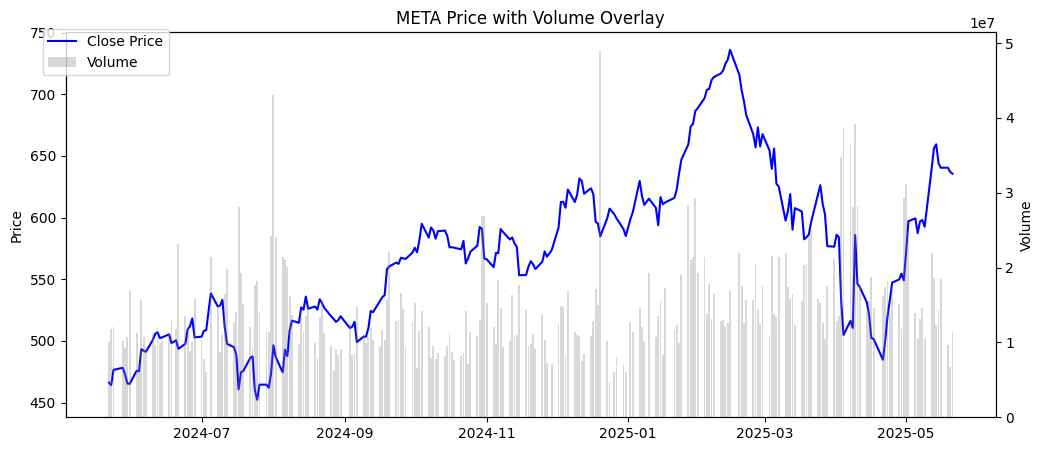

In [ ]:
#Price + traded volume — useful for market sentiment.
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# Use the 'data' DataFrame which contains the 'Volume' column
ax1.plot(data.index, data['Close'], color='blue', label='Close Price')
ax2.bar(data.index, data['Volume'], color='gray', alpha=0.3, label='Volume')

ax1.set_title('META Price with Volume Overlay')
ax1.set_ylabel('Price')
ax2.set_ylabel('Volume')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()

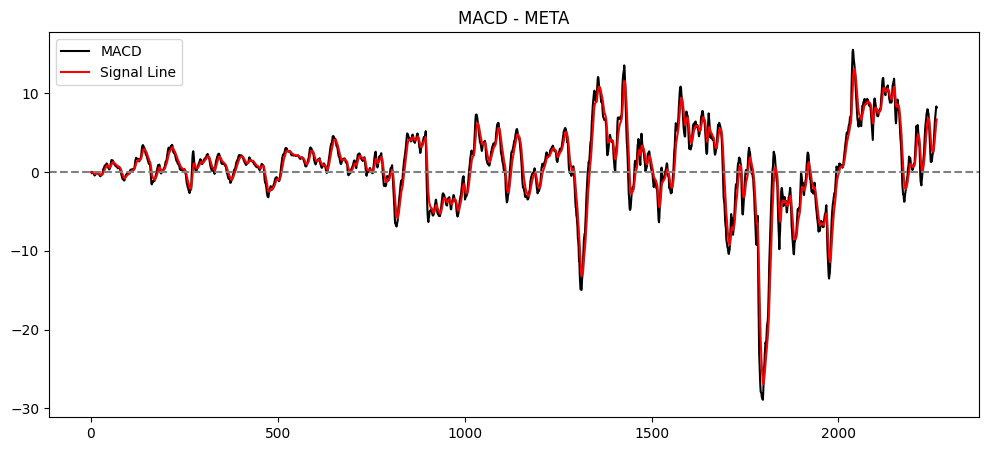

In [ ]:
#Shows momentum and trend changes.
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['MACD'], label='MACD', color='black')
plt.plot(df['Signal'], label='Signal Line', color='red')
plt.axhline(0, linestyle='--', color='gray')
plt.title('MACD - META')
plt.legend()
plt.show()


ARIMA Model (Autoregressive Integrated Moving Average)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.11/dist-packages/st

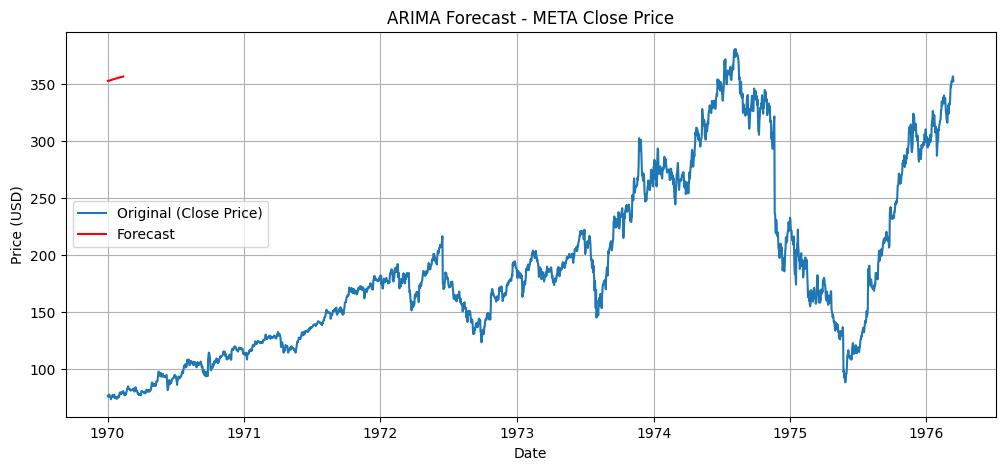

In [ ]:
# Forecasting Methods ARIMA Model (Autoregressive Integrated Moving Average)

# Assign the 'Close' column of the DataFrame df to the variable ts
ts = df['Close']

model = ARIMA(ts, order=(2, 1, 2))
model_fit = model.fit()

#Forecast future values
forecast = model_fit.forecast(steps=30)
plt.figure(figsize=(12, 5))
plt.plot(ts, label='Original (Close Price)')
plt.plot(pd.date_range(start=ts.index[-1], periods=31, freq='B')[1:], forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast - META Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

Prophet Forecasting (Meta)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp67hji9lh/0oz5r8xz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp67hji9lh/8cxmw9ho.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13223', 'data', 'file=/tmp/tmp67hji9lh/0oz5r8xz.json', 'init=/tmp/tmp67hji9lh/8cxmw9ho.json', 'output', 'file=/tmp/tmp67hji9lh/prophet_modellylwe5f2/prophet_model-20250522123406.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:34:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:34:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


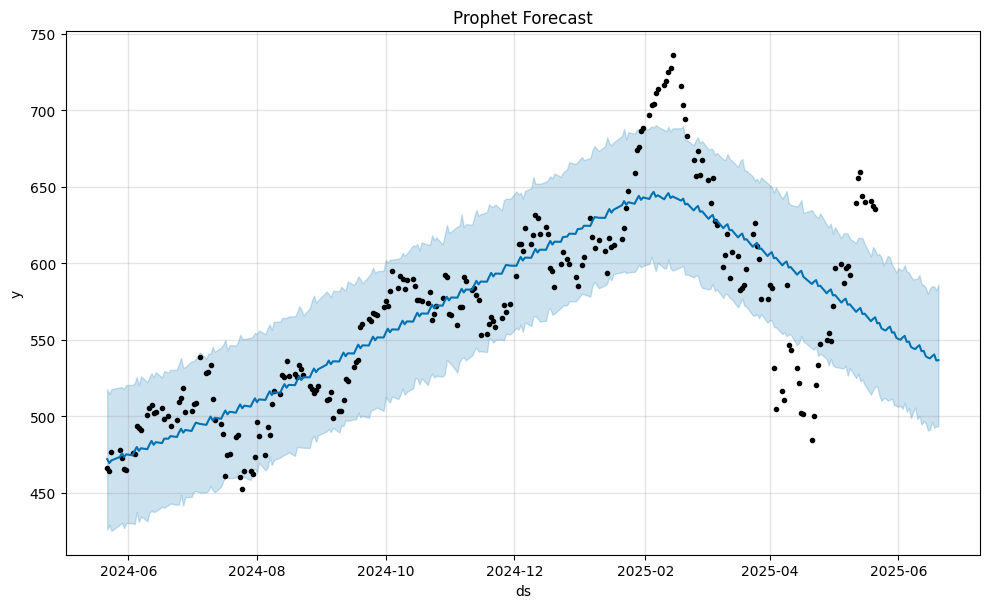

In [ ]:
from prophet import Prophet
import pandas as pd # Ensure pandas is imported

# Prepare Data
df = data.reset_index()
df = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Remove timezone information from the 'ds' column
df['ds'] = df['ds'].dt.tz_localize(None)

# Initialize and Fit Prophet
model = Prophet()
model.fit(df)

# Future Dates
future = model.make_future_dataframe(periods=30)

# Forecast
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

SARIMA Forecasting (with Seasonality)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



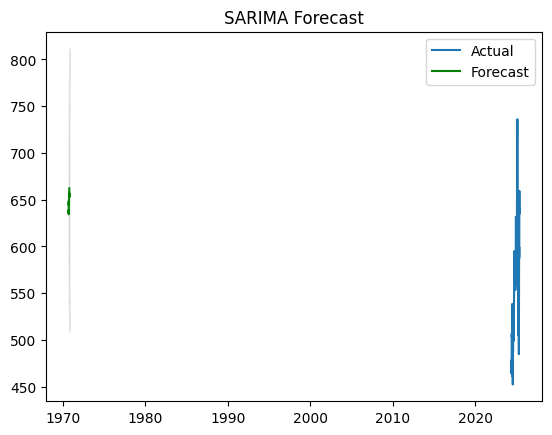

In [ ]:
# Fit SARIMA model (adjust parameters)
# Instead of passing the entire DataFrame, select the 'Close' column
model = SARIMAX(data['Close'], order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()

# Forecast
forecast = model_fit.get_forecast(steps=30)
forecast_ci = forecast.conf_int()

# Plot
plt.plot(data['Close'], label='Actual')  # Plot the 'Close' column for actual data
forecast.predicted_mean.plot(label='Forecast', color='green')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=0.1)
plt.title('SARIMA Forecast')
plt.legend()
plt.show()

 LSTM Forecasting (using TensorFlow/Keras)

In [ ]:
#Prepare for Prophet
# Instead of selecting 'Date' as a column, reset the index
# and then select 'Date' and 'Close'
df = data.reset_index()[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Prepare Data
# Print the shape of 'data' to check if it's empty
print("Shape of data:", data.shape)
scaler = MinMaxScaler(feature_range=(0,1))
# scaled_data = scaler.fit_transform(data.values.reshape(-1,1))
# Check if 'data.values' is empty before reshaping
if data.empty:
    print("Error: 'data' DataFrame is empty. Please check data loading or preprocessing.")
else:
    # *** The Fix: Select only the 'Close' column for scaling ***
    scaled_data = scaler.fit_transform(data[['Close']].values.reshape(-1,1))


# Split into train/test
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create sequences
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X_train, y_train = create_dataset(train, time_step)
X_test, y_test = create_dataset(test, time_step)

# Reshape for LSTM input (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

# Add a check to ensure X_test is not empty before reshaping
if X_test.shape[0] > 0 and X_test.shape[1] > 0:
    X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1], 1)
    # Build LSTM Model
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
    model.add(LSTM(50))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train
    model.fit(X_train, y_train, epochs=20, batch_size=32)

    # Predict
    train_predict = model.predict(X_train)
    test_predict  = model.predict(X_test)

    # Inverse Scaling
    train_predict = scaler.inverse_transform(train_predict)
    test_predict  = scaler.inverse_transform(test_predict)

    # Plot
    plt.plot(data.index, data['Close'], label='Actual') # Changed data.values to data['Close']
    plt.plot(data.index[time_step:len(train_predict)+time_step], train_predict, label='Train Predict')
    # Adjust the x-axis for the test prediction plot to match the length of the test_predict array
    # We need to calculate the correct starting index for the test set based on the training size and time_step
    test_start_index = len(train_predict) + time_step # The starting index in the original data for the test predictions
    test_end_index = test_start_index + len(test_predict) # The ending index in the original data for the test predictions

    # Ensure the indices are within the bounds of data.index
    plt.plot(data.index[test_start_index:test_end_index], test_predict, label='Test Predict')

    plt.title('LSTM Forecast')
    plt.legend()
    plt.show()
else:
    print("Error: Test dataset is too small to create sequences with the specified time_step.")
    # You might want to skip the rest of the LSTM code or handle this case differently
    # For example, you could train and plot only on the training data if the test set is too small.

Shape of data: (250, 7)
Error: Test dataset is too small to create sequences with the specified time_step.


Split into Train/Test

In [ ]:
# 80% train, 20% test
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]


Shape of data: (250, 7)
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.1713
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0287
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0231
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0189
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0164
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0115
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0141
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0115
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0139
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0107
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0128
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0116
Epoch 13/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0135
Epoch 14/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0098
Epoch 15/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0121
Epoch 16/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/

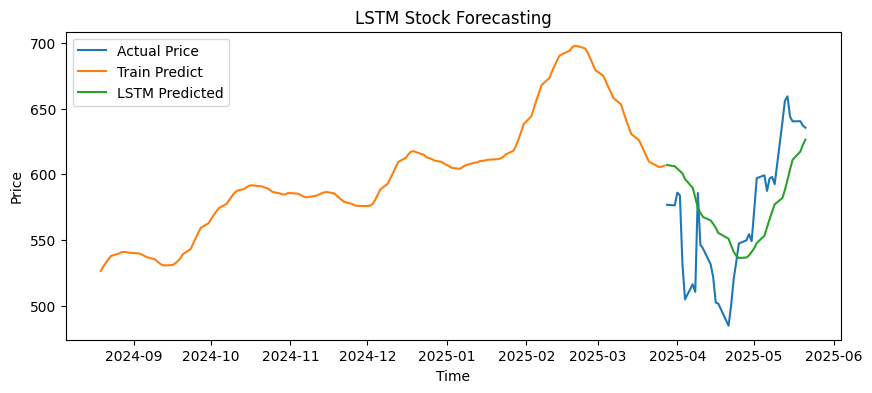

LSTM RMSE: 42.080615876037555


In [ ]:
# Prepare Data
# Print the shape of 'data' to check if it's empty
print("Shape of data:", data.shape)

# *** The Fix: Select only the 'Close' column for scaling ***
# Scale only the 'Close' column
scaler = MinMaxScaler(feature_range=(0,1))
if data.empty:
    print("Error: 'data' DataFrame is empty. Please check data loading or preprocessing.")
else:
    # Scale only the 'Close' column
    scaled_close_price = scaler.fit_transform(data[['Close']].values)

# Create sequences for LSTM
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(seq_length, len(data)):
        # The data input here is the scaled 'Close' price, which has only one feature
        x.append(data[i - seq_length:i, 0]) # Select the single feature (column 0)
        y.append(data[i, 0]) # Select the single feature (column 0)
    return np.array(x), np.array(y)

# Define sequence length
sequence_length = 60

# Create sequences
# Use the scaled_close_price array which has only one feature
x_all, y_all = create_sequences(scaled_close_price, sequence_length)

# Train-test split
train_size = int(len(x_all) * 0.8)
x_train = x_all[:train_size]
y_train = y_all[:train_size]
x_test = x_all[train_size:]
y_test = y_all[train_size:]

# Reshape inputs to LSTM format: (samples, timesteps, features)
# The features dimension should now be 1 because create_sequences worked on a single column
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

# Add a check to ensure x_test is not empty before reshaping
if x_test.shape[0] > 0 and x_test.shape[1] > 0:
    x_test  = x_test.reshape((x_test.shape[0],  x_test.shape[1], 1))

    # Build LSTM Model
    model_lstm = Sequential() # Use the variable name from the original code
    model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model_lstm.add(Dropout(0.2)) # Add Dropout layer as in the original code
    model_lstm.add(LSTM(units=50, return_sequences=False))
    model_lstm.add(Dropout(0.2)) # Add Dropout layer as in the original code
    model_lstm.add(Dense(units=1)) # Use units=1 as in the original code

    model_lstm.compile(optimizer='adam', loss='mean_squared_error')

    # Train
    model_lstm.fit(x_train, y_train, epochs=20, batch_size=32) # Use model_lstm

    # Predict
    train_predict = model_lstm.predict(x_train) # Use model_lstm
    test_predict  = model_lstm.predict(x_test)   # Use model_lstm

    # Inverse Scaling
    # Inverse transform the predictions (which are on a single feature)
    train_predict = scaler.inverse_transform(train_predict)
    test_predict  = scaler.inverse_transform(test_predict)
    # Inverse transform the actual test values
    real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))  # Ensure shape match

    # Plot
    plt.figure(figsize=(10, 4)) # Match the figure size
    # Adjust the plotting of the actual data
    # The actual prices for the plot should correspond to the time range of the test set.
    # The indices of real_prices align with the indices of x_test in the original data after creating sequences.
    # The start index in the original data for the test set is train_size (from x_all split) + sequence_length.
    actual_plot_indices = data.index[train_size + sequence_length : train_size + sequence_length + len(real_prices)]
    plt.plot(actual_plot_indices, real_prices, label='Actual Price')

    # Adjust the x-axis for the predicted values.
    # train_predict corresponds to the sequence_length to train_size + sequence_length -1 in the original data indices.
    train_predict_indices = data.index[sequence_length : sequence_length + len(train_predict)]
    plt.plot(train_predict_indices, train_predict, label='Train Predict')

    # test_predict corresponds to train_size + sequence_length to train_size + sequence_length + len(test_predict) - 1
    test_predict_indices = data.index[train_size + sequence_length : train_size + sequence_length + len(test_predict)]
    plt.plot(test_predict_indices, test_predict, label='LSTM Predicted') # Use 'LSTM Predicted' as in the original code

    plt.title('LSTM Stock Forecasting') # Match the title
    plt.xlabel('Time') # Match the label
    plt.ylabel('Price') # Match the label
    plt.legend()
    plt.show()

    # RMSE
    # Use test_predict for the predicted values instead of predicted_prices
    rmse_lstm = np.sqrt(mean_squared_error(real_prices, test_predict))
    print("LSTM RMSE:", rmse_lstm)

else:
    print("Error: Test dataset is too small to create sequences with the specified time_step.")
    # You might want to skip the rest of the LSTM code or handle this case differently
    # For example, you could train and plot only on the training data if the test set is too small.

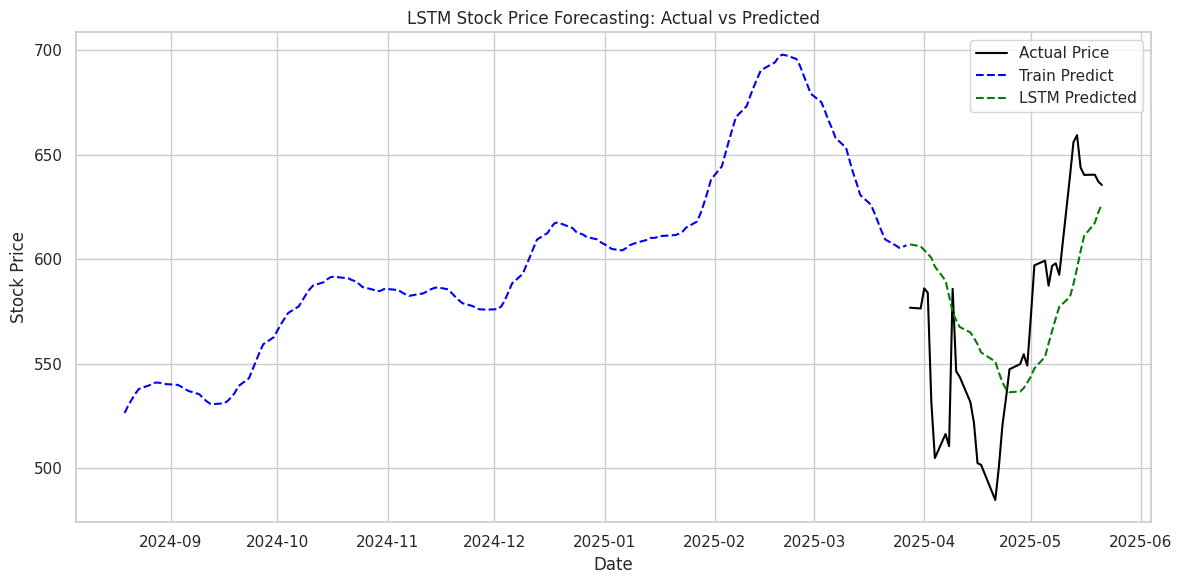

In [89]:
# data.index must be a DateTimeIndex or comparable index

# Plot setup
plt.figure(figsize=(12, 6))

# Actual prices for test period
actual_plot_indices = data.index[train_size + sequence_length : train_size + sequence_length + len(real_prices)]
plt.plot(actual_plot_indices, real_prices, label='Actual Price', color='black')

# Predicted prices for train period
train_predict_indices = data.index[sequence_length : sequence_length + len(train_predict)]
plt.plot(train_predict_indices, train_predict, label='Train Predict', color='blue', linestyle='--')

# Predicted prices for test period
test_predict_indices = data.index[train_size + sequence_length : train_size + sequence_length + len(test_predict)]
plt.plot(test_predict_indices, test_predict, label='LSTM Predicted', color='green', linestyle='--')

# Titles and labels
plt.title('LSTM Stock Price Forecasting: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


In [92]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 200 entries, 2024-05-22 00:00:00-04:00 to 2025-03-11 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          200 non-null    float64
 1   High          200 non-null    float64
 2   Low           200 non-null    float64
 3   Close         200 non-null    float64
 4   Volume        200 non-null    int64  
 5   Dividends     200 non-null    float64
 6   Stock Splits  200 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 12.5 KB


In [93]:
test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 50 entries, 2025-03-12 00:00:00-04:00 to 2025-05-21 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          50 non-null     float64
 1   High          50 non-null     float64
 2   Low           50 non-null     float64
 3   Close         50 non-null     float64
 4   Volume        50 non-null     int64  
 5   Dividends     50 non-null     float64
 6   Stock Splits  50 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 3.1 KB


Accuracy Metrics

RMSE: Penalizes large errors more, gives idea of average prediction error.

MAE: Average absolute difference between predicted and actual.

MAPE: Percentage error, easy to interpret (e.g., 5% error).

R² Score: Closer to 1 means better fit; shows how well the model explains the variance.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inverse transform the predictions and real values
predicted_prices = scaler.inverse_transform(model_lstm.predict(x_test))
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE
rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))
# MAE
mae = mean_absolute_error(real_prices, predicted_prices)
# MAPE
mape = np.mean(np.abs((real_prices - predicted_prices) / real_prices)) * 100
# R² Score
r2 = r2_score(real_prices, predicted_prices)

# Display results
print("LSTM Stock Forecasting Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R² Score: {r2:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
LSTM Stock Forecasting Metrics:
RMSE: 42.0806
MAE: 35.8688
MAPE: 6.44%
R² Score: 0.2778


<ipython-input-87-7a2ce36ddd54>:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




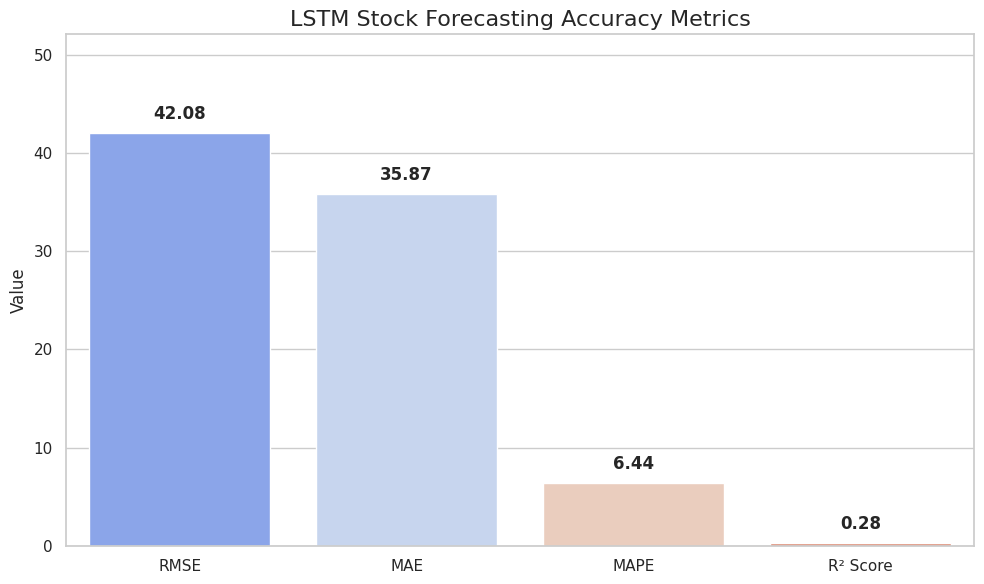

In [87]:
# Metrics
metrics = ['RMSE', 'MAE', 'MAPE', 'R² Score']
values = [42.0806, 35.8688, 6.44, 0.2778]

# Set plot style
sns.set(style="whitegrid")

# Create barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=metrics, y=values, palette="coolwarm")

# Add value labels on bars
for i, v in enumerate(values):
    ax.text(i, v + 1, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

# Title and labels
plt.title("LSTM Stock Forecasting Accuracy Metrics", fontsize=16)
plt.ylabel("Value")
plt.ylim(0, max(values) + 10)

# Show plot
plt.tight_layout()
plt.show()


In [96]:
# Make sure real_prices and test_predict are in the correct shape
mape = mean_absolute_percentage_error(real_prices, test_predict)

# Accuracy is 100 - MAPE
accuracy = 100 - (mape * 100)

print(f"MAPE: {mape*100:.2f}%")
print(f"Prediction Accuracy: {accuracy:.2f}%")


MAPE: 6.44%
Prediction Accuracy: 93.56%


Future Price Forecasting

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━

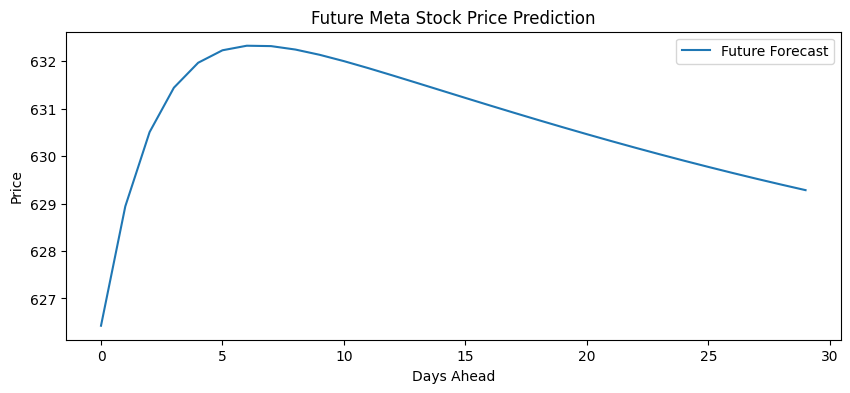

In [ ]:
def predict_future(model, last_sequence, days_ahead, scaler):
    future_predictions = []
    input_seq = last_sequence.copy()

    for _ in range(days_ahead):
        pred = model.predict(input_seq.reshape(1, -1, 1))[0][0]
        future_predictions.append(pred)
        input_seq = np.append(input_seq[1:], [[pred]], axis=0)

    return scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Example: predict next 30 days
last_sequence = x_test[-1]
future_prices = predict_future(model_lstm, last_sequence, days_ahead=30, scaler=scaler)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(future_prices, label='Future Forecast')
plt.title('Future Meta Stock Price Prediction')
plt.xlabel('Days Ahead')
plt.ylabel('Price')
plt.legend()
plt.show()


Save Model & Scaler

In [ ]:

model_lstm.save("lstm_meta_stock_model.h5")

import joblib
joblib.dump(scaler, "scaler.save")


['scaler.save']